# IEMOCAP EDA

Quick figures to understand dataset composition before modeling.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

repo_root = Path.cwd().parents[0]
csv_path = repo_root / "datasets/IEMOCAP/iemocap_full_dataset.csv"
out_dir = repo_root / "analysis" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(csv_path)
df["emotion"] = df["emotion"].astype(str).str.strip().str.lower()
df["method"] = df["method"].astype(str).str.strip().str.lower()
df["gender"] = df["gender"].astype(str).str.strip().str.upper()

df.head()



,session,method,gender,emotion,n_annotators,agreement,path
0,1,script,F,neu,3,3,Session1/sentences/wav/Ses01F_script02_1/Ses01...
1,1,script,F,fru,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...
2,1,script,F,xxx,0,0,Session1/sentences/wav/Ses01F_script02_1/Ses01...
3,1,script,F,sur,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...
4,1,script,F,neu,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...


In [30]:
def save_fig(fig: plt.Figure, name: str) -> None:
    fig.tight_layout()
    fig.savefig(out_dir / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


def bar_plot(series: pd.Series, title: str, xlabel: str, ylabel: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(8, 5))
    series.plot(kind="bar", ax=ax, color="#2f4b7c")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    return fig


def pie_plot_thesis(
    series: pd.Series,
    title: str,
    legend_title: str = "Emotion",
    min_pct_label: float = 4.0,
) -> plt.Figure:
    # Keep slices in descending order for readability.
    series = series.sort_values(ascending=False)
    total = series.sum()

    fig, ax = plt.subplots(figsize=(8.6, 5.6))
    cmap = plt.get_cmap("tab20")
    colors = [cmap(i) for i in range(len(series))]

    def autopct_fn(pct: float) -> str:
        return f"{pct:.1f}%" if pct >= min_pct_label else ""

    wedges, _, autotexts = ax.pie(
        series.values,
        labels=None,
        colors=colors,
        startangle=90,
        counterclock=False,
        autopct=autopct_fn,
        pctdistance=0.78,
        wedgeprops={"width": 0.5, "edgecolor": "white", "linewidth": 1.0},
    )

    for t in autotexts:
        t.set_fontsize(9)
        t.set_color("black")

    legend_labels = [
        f"{label}: {value:,} ({value / total * 100:.1f}%)"
        for label, value in series.items()
    ]

    ax.legend(
        wedges,
        legend_labels,
        title=legend_title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    ax.set_title(title, pad=10)
    ax.set_aspect("equal")

    return fig



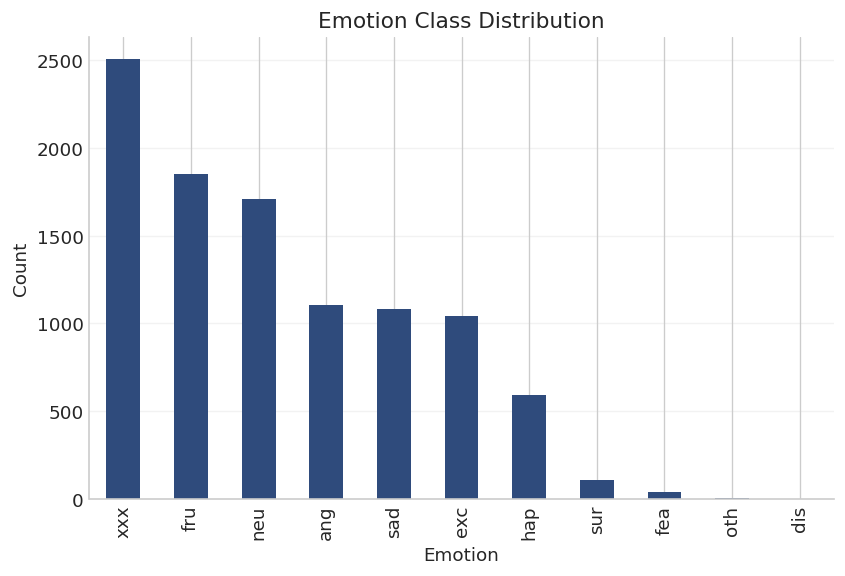

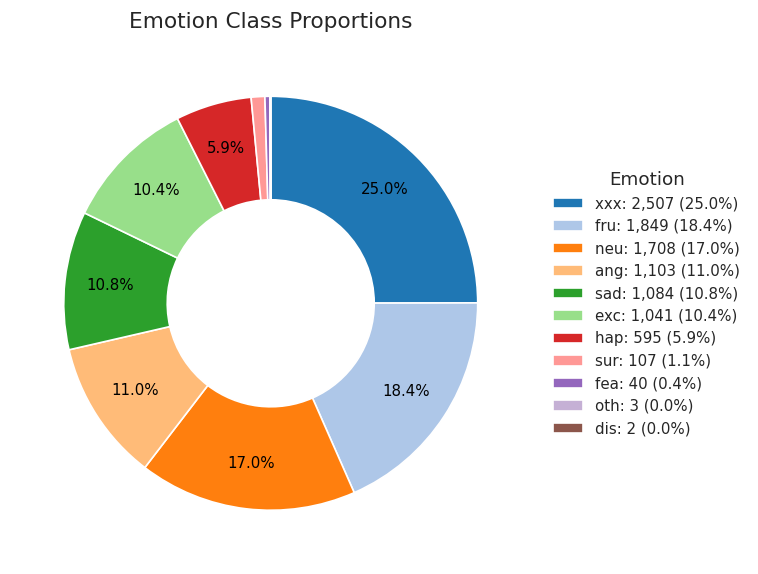

emotion
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
sur     107
fea      40
oth       3
dis       2
Name: count, dtype: int64

In [31]:
# Emotion distribution (including 'xxx')
emotion_counts = df["emotion"].value_counts()
fig = bar_plot(
    emotion_counts,
    "Emotion Class Distribution",
    "Emotion",
    "Count",
)
plt.show()

fig = pie_plot_thesis(
    emotion_counts,
    "Emotion Class Proportions",
    legend_title="Emotion",
    min_pct_label=4.0,
)
plt.show()

emotion_counts



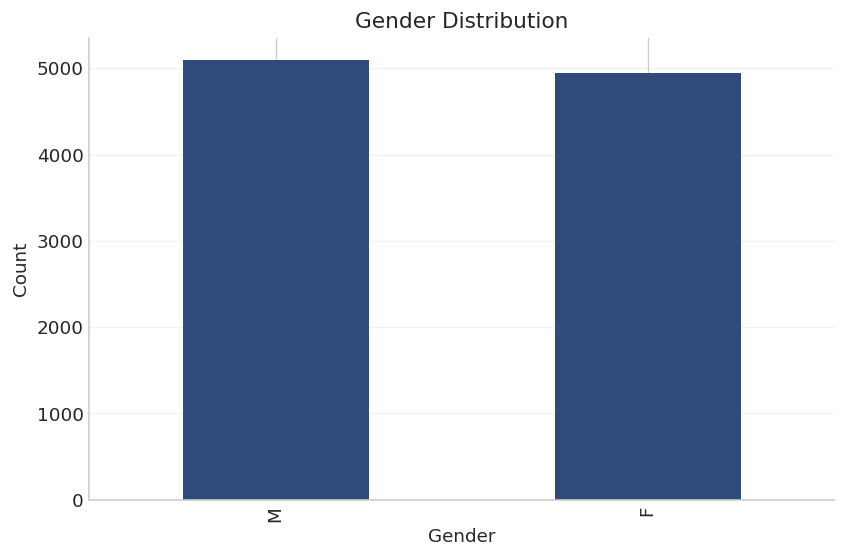

gender
M    5098
F    4941
Name: count, dtype: int64

In [32]:
# Gender distribution
gender_counts = df["gender"].value_counts()
fig = bar_plot(gender_counts, "Gender Distribution", "Gender", "Count")
plt.show()

gender_counts

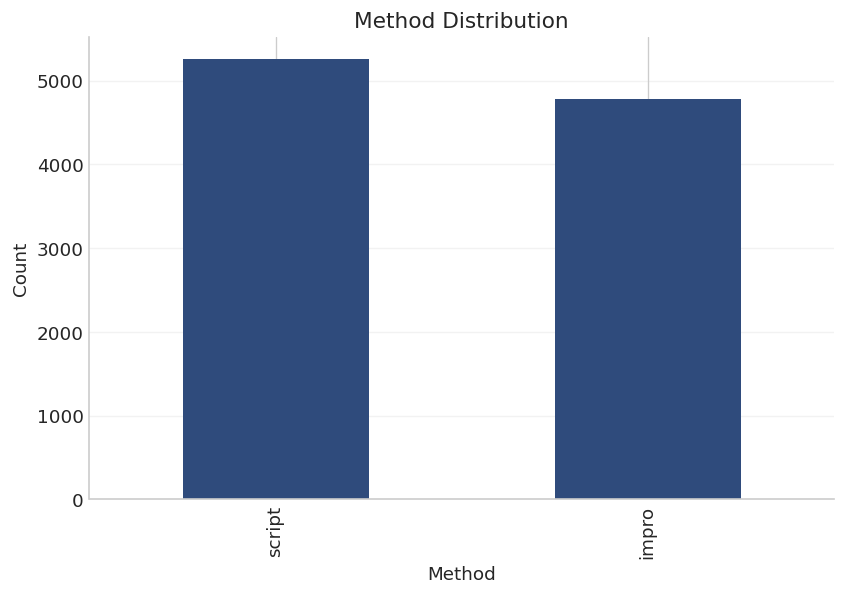

method
script    5255
impro     4784
Name: count, dtype: int64

In [33]:
# Method distribution
method_counts = df["method"].value_counts()
fig = bar_plot(method_counts, "Method Distribution", "Method", "Count")
plt.show()

method_counts

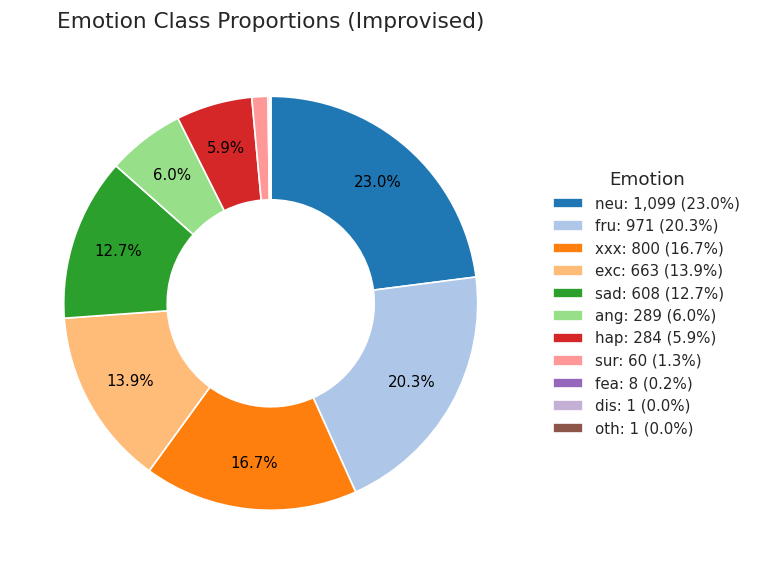

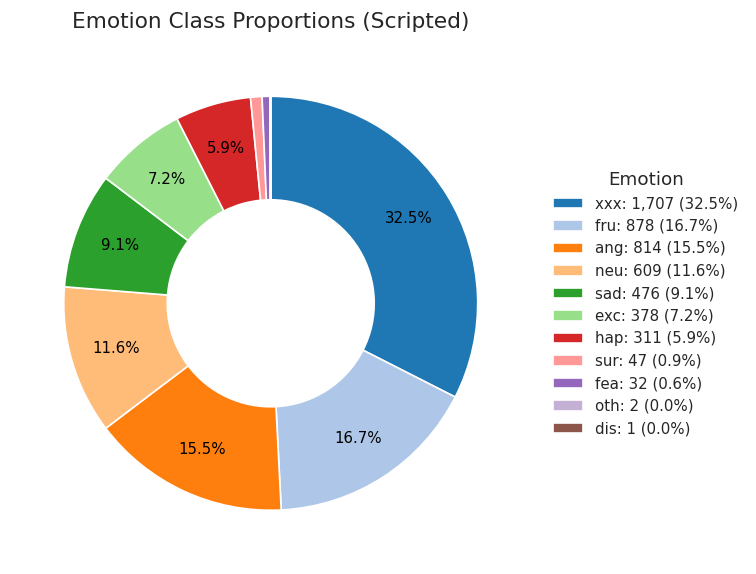

In [34]:
# Emotion class pie charts split by method (improvised vs scripted)
for method_label, title in [("impro", "Improvised"), ("script", "Scripted")]:
    subset = df[df["method"] == method_label]
    counts = subset["emotion"].value_counts()
    fig = pie_plot_thesis(
        counts,
        f"Emotion Class Proportions ({title})",
        legend_title="Emotion",
        min_pct_label=4.0,
    )
    plt.show()



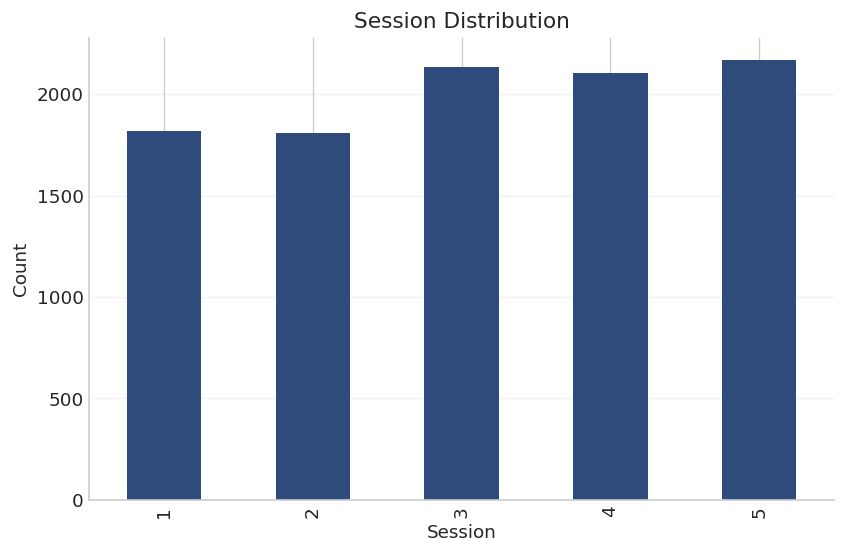

session
1    1819
2    1811
3    2136
4    2103
5    2170
Name: count, dtype: int64

In [35]:
# Session distribution
session_counts = df["session"].value_counts().sort_index()
fig = bar_plot(session_counts, "Session Distribution", "Session", "Count")
plt.show()

session_counts

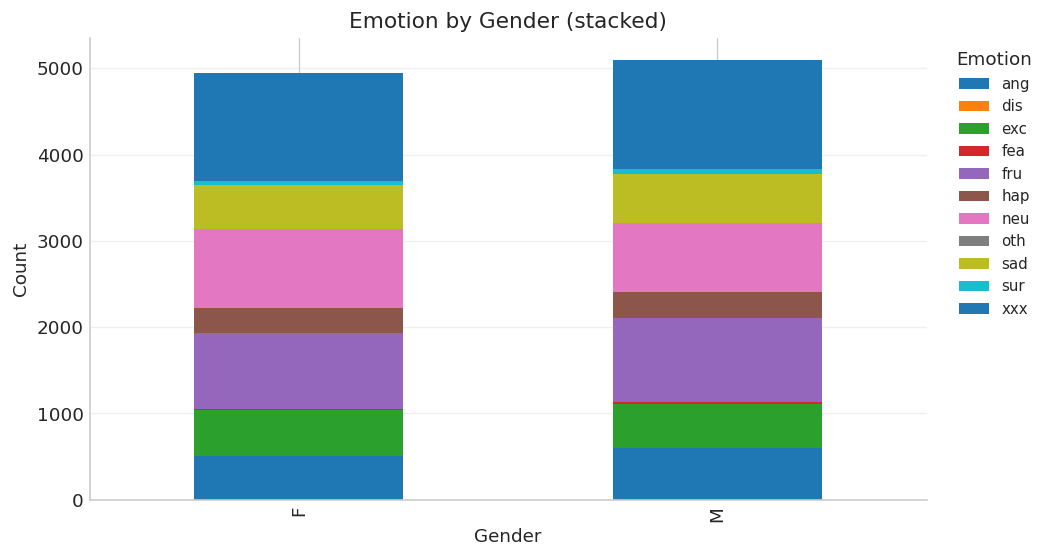

emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur,xxx
gender,,,,,,,,,,,
F,505,1,529,16,883,291,911,2,509,48,1246
M,598,1,512,24,966,304,797,1,575,59,1261


In [36]:
# Emotion by gender (stacked bar)
gender_emotion = pd.crosstab(df["gender"], df["emotion"])
fig, ax = plt.subplots(figsize=(9, 5))
gender_emotion.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Emotion by Gender (stacked)")
ax.set_xlabel("Gender")
ax.set_ylabel("Count")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.show()

gender_emotion

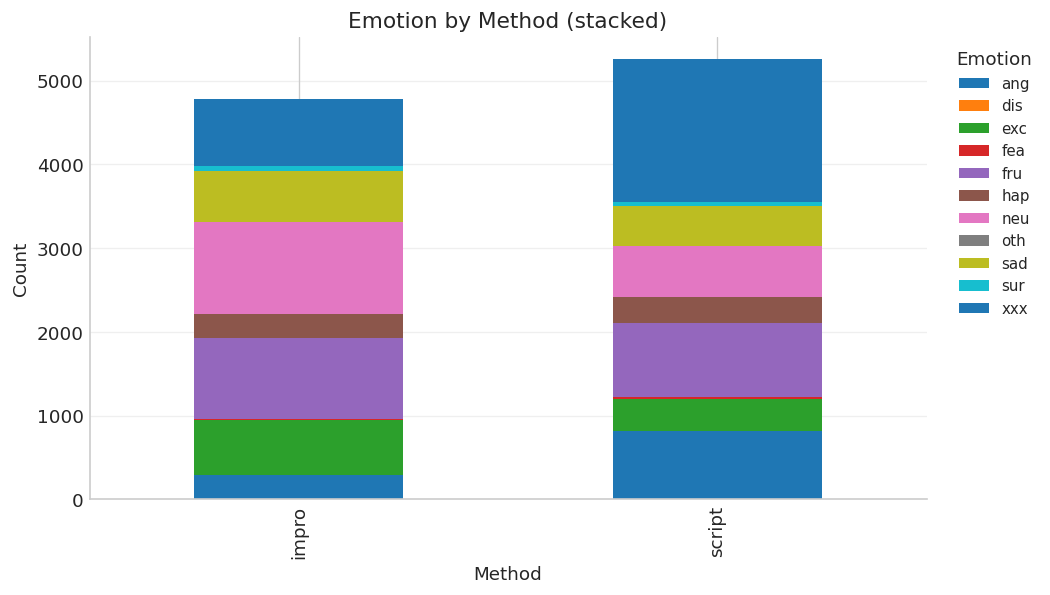

emotion,ang,dis,exc,fea,fru,hap,neu,oth,sad,sur,xxx
method,,,,,,,,,,,
impro,289,1,663,8,971,284,1099,1,608,60,800
script,814,1,378,32,878,311,609,2,476,47,1707


In [37]:
# Emotion by method (stacked bar)
method_emotion = pd.crosstab(df["method"], df["emotion"])
fig, ax = plt.subplots(figsize=(9, 5))
method_emotion.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Emotion by Method (stacked)")
ax.set_xlabel("Method")
ax.set_ylabel("Count")
ax.legend(title="Emotion", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.show()

method_emotion

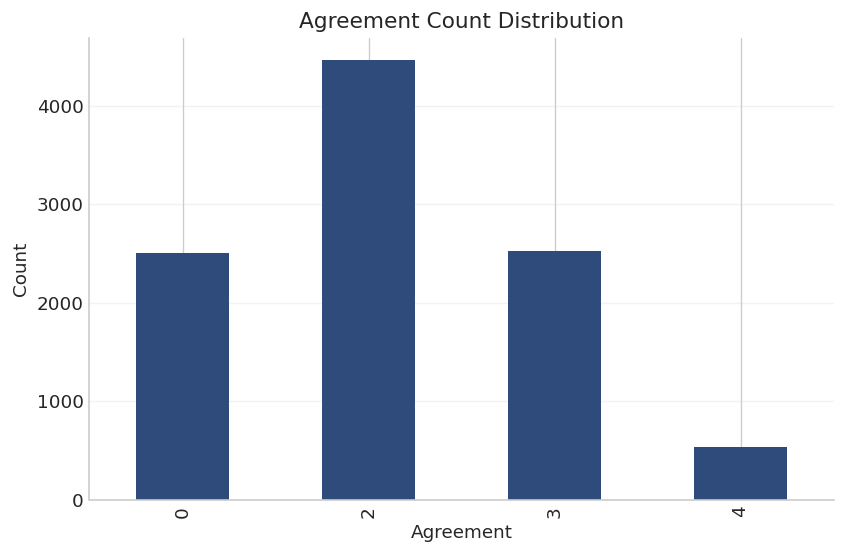

agreement
0    2507
2    4466
3    2526
4     540
Name: count, dtype: int64

In [38]:
# Agreement distribution
agreement_counts = df["agreement"].value_counts().sort_index()
fig = bar_plot(
    agreement_counts,
    "Agreement Count Distribution",
    "Agreement",
    "Count",
)
plt.show()

agreement_counts

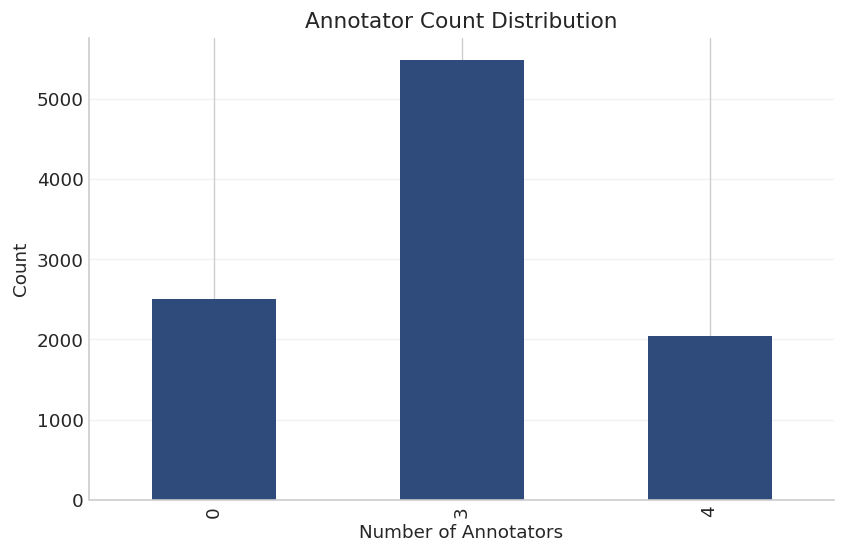

n_annotators
0    2507
3    5490
4    2042
Name: count, dtype: int64

In [39]:
# Annotator count distribution
annotator_counts = df["n_annotators"].value_counts().sort_index()
fig = bar_plot(
    annotator_counts,
    "Annotator Count Distribution",
    "Number of Annotators",
    "Count",
)
plt.show()

annotator_counts

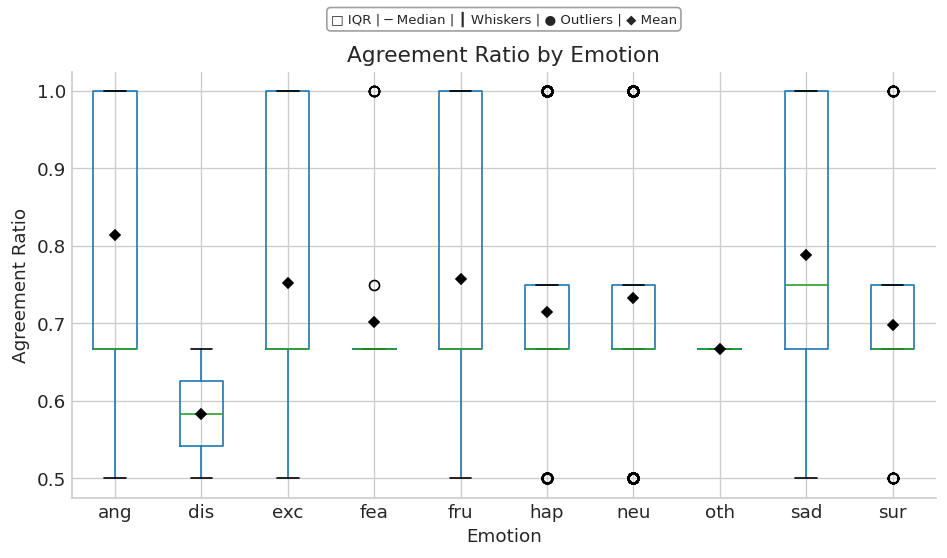

,count,mean,50%,min,max
emotion,,,,,
ang,1103.0,0.814294,0.666667,0.500000,1.000000
dis,2.0,0.583333,0.583333,0.500000,0.666667
exc,1041.0,0.752161,0.666667,0.500000,1.000000
fea,40.0,0.702083,0.666667,0.666667,1.000000
fru,1849.0,0.757211,0.666667,0.500000,1.000000
hap,595.0,0.714706,0.666667,0.500000,1.000000
neu,1708.0,0.732923,0.666667,0.500000,1.000000
oth,3.0,0.666667,0.666667,0.666667,0.666667
sad,1084.0,0.787592,0.750000,0.500000,1.000000


In [40]:
# Agreement ratio by emotion (excluding rows with 0 annotators)
ratio_df = df[df["n_annotators"] > 0].copy()
ratio_df["agreement_ratio"] = ratio_df["agreement"] / ratio_df["n_annotators"]

fig, ax = plt.subplots(figsize=(9, 5))
ratio_df.boxplot(
    column="agreement_ratio",
    by="emotion",
    ax=ax,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "black", "markeredgecolor": "black", "markersize": 4},
)
fig.subplots_adjust(top=0.86)
fig.text(
    0.5,
    0.96,
    "□ IQR | ─ Median | ┃ Whiskers | ● Outliers | ◆ Mean",
    ha="center",
    va="top",
    fontsize=8,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75, edgecolor="gray"),
)
ax.set_title("Agreement Ratio by Emotion")
ax.set_xlabel("Emotion")
ax.set_ylabel("Agreement Ratio")
fig.suptitle("")
plt.show()

ratio_df.groupby("emotion")["agreement_ratio"].describe()[["count", "mean", "50%", "min", "max"]]

In [41]:
# Session-based train/test split (Session 5 as test)
valid_df = df[(df["emotion"] != "xxx") & (df["agreement"] > 0)].copy()
session_counts = valid_df["session"].value_counts().sort_index()

train_sessions = [1, 2, 3, 4]
test_sessions = [5]

train_count = session_counts.loc[train_sessions].sum()
test_count = session_counts.loc[test_sessions].sum()
total_count = train_count + test_count

pd.DataFrame(
    {
        "count": [train_count, test_count],
        "ratio": [train_count / total_count, test_count / total_count],
    },
    index=["train (sessions 1-4)", "test (session 5)"],
)

,count,ratio
train (sessions 1-4),5882,0.780935
test (session 5),1650,0.219065


In [42]:
# Audio clip duration analysis (based on file paths)
from pathlib import Path
import librosa

audio_root = repo_root / "datasets" / "IEMOCAP"
durations = []
missing = []

for rel_path in df["path"].tolist():
    audio_path = audio_root / rel_path
    if not audio_path.exists():
        missing.append(str(audio_path))
        continue
    try:
        duration = librosa.get_duration(path=audio_path)
        durations.append(duration)
    except Exception:
        continue

durations_series = pd.Series(durations, name="duration_s")
durations_series.describe()

count    10039.000000
mean         4.460078
std          3.064676
min          0.584937
25%          2.330000
50%          3.519938
75%          5.709937
max         34.138750
Name: duration_s, dtype: float64